# Credit Risk Modelling Machine Learning Project
## Credit Utilization Feature Engineering & Modeling Tasks

- Generate a new feature called **`credit_utilization_per_income`**. This is simply a ratio of `credit_utilization_ratio` and `loan_to_income`.

- Plot **KDE plot** and record your insights in the notebook.

- Use this feature in the remaining of the notebook all the way till modelling.

- Install `bayesian-optimization` module by running:  
  `pip install bayesian-optimization`

- **Attempt 1:** Use internet/ChatGPT to do some research and write code to use `BayesianOptimization` to find best parameters for logistic regression.

- **Attempt 2:** Use `GridSearchCV` and `XGBoost` to train your model and find best parameters.

- Install `shap` by running:  
  `pip install shap`

- `shap` is a Python library used for AI explainability. Use `TreeExplainer` from this library to explain the best performing XGBoost model that you got in **Attempt 2**.

- Plot `dependence_plot` for `credit_utilization_ratio`.

- Use `shap.force_plot` to draw a plot for a single prediction from `X_test_encoded` array.

In [1]:
#Import the necessary libraries 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
print(f"Libraries are imported successfully")

Libraries are imported successfully


In [2]:
#Display format fixed throughout the project
pd.set_option('display.float_format',lambda x: '{:.2f}'.format(x))
np.set_printoptions(suppress=True)

In [3]:
#Load the data on the dataframe
customers = pd.read_csv('../data/customers.csv')
loans = pd.read_csv('../data/loans.csv')
bureau = pd.read_csv('../data/bureau_data.csv')
print(f"Customers, Loans and Bureau Data loaded successfully")

Customers, Loans and Bureau Data loaded successfully


In [4]:
#Customer dataset analysis
customers.shape

(50000, 12)

In [5]:
#Loans dataset analysis
loans.shape

(50000, 15)

In [6]:
#Bureau dataset analysis
bureau.shape

(50000, 8)

In [7]:
customers.head(3)

,cust_id,age,gender,marital_status,employment_status,income,number_of_dependants,residence_type,years_at_current_address,city,state,zipcode
0,C00001,44,M,Married,Self-Employed,2586000,3,Owned,27,Delhi,Delhi,110001
1,C00002,38,M,Married,Salaried,1206000,3,Owned,4,Chennai,Tamil Nadu,600001
2,C00003,46,F,Married,Self-Employed,2878000,3,Owned,24,Kolkata,West Bengal,700001


In [8]:
loans.head(3)

,loan_id,cust_id,loan_purpose,loan_type,sanction_amount,loan_amount,processing_fee,gst,net_disbursement,loan_tenure_months,principal_outstanding,bank_balance_at_application,disbursal_date,installment_start_dt,default
0,L00001,C00001,Auto,Secured,3004000,2467000,49340.00,444060,1973600,33,1630408,873386,2019-07-24,2019-08-10,False
1,L00002,C00002,Home,Secured,4161000,3883000,77660.00,698940,3106400,30,709309,464100,2019-07-24,2019-08-15,False
2,L00003,C00003,Personal,Unsecured,2401000,2170000,43400.00,390600,1736000,21,1562399,1476042,2019-07-24,2019-08-21,False


In [9]:
bureau.head(3)

,cust_id,number_of_open_accounts,number_of_closed_accounts,total_loan_months,delinquent_months,total_dpd,enquiry_count,credit_utilization_ratio
0,C00001,1,1,42,0,0,3,7
1,C00002,3,1,96,12,60,5,4
2,C00003,2,1,82,24,147,6,58


In [10]:
#Merge the dataset so that the modelling can be done on a single dataset
df = pd.merge(customers, loans, on = 'cust_id')
df.head(3)

,cust_id,age,gender,marital_status,employment_status,income,number_of_dependants,residence_type,years_at_current_address,city,...,loan_amount,processing_fee,gst,net_disbursement,loan_tenure_months,principal_outstanding,bank_balance_at_application,disbursal_date,installment_start_dt,default
0,C00001,44,M,Married,Self-Employed,2586000,3,Owned,27,Delhi,...,2467000,49340.00,444060,1973600,33,1630408,873386,2019-07-24,2019-08-10,False
1,C00002,38,M,Married,Salaried,1206000,3,Owned,4,Chennai,...,3883000,77660.00,698940,3106400,30,709309,464100,2019-07-24,2019-08-15,False
2,C00003,46,F,Married,Self-Employed,2878000,3,Owned,24,Kolkata,...,2170000,43400.00,390600,1736000,21,1562399,1476042,2019-07-24,2019-08-21,False


In [11]:
#Merge with bureau dataset so that one cummulative dataframe can be built
df = pd.merge(df, bureau, on = 'cust_id')
df.head(3)

,cust_id,age,gender,marital_status,employment_status,income,number_of_dependants,residence_type,years_at_current_address,city,...,disbursal_date,installment_start_dt,default,number_of_open_accounts,number_of_closed_accounts,total_loan_months,delinquent_months,total_dpd,enquiry_count,credit_utilization_ratio
0,C00001,44,M,Married,Self-Employed,2586000,3,Owned,27,Delhi,...,2019-07-24,2019-08-10,False,1,1,42,0,0,3,7
1,C00002,38,M,Married,Salaried,1206000,3,Owned,4,Chennai,...,2019-07-24,2019-08-15,False,3,1,96,12,60,5,4
2,C00003,46,F,Married,Self-Employed,2878000,3,Owned,24,Kolkata,...,2019-07-24,2019-08-21,False,2,1,82,24,147,6,58


In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 33 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   cust_id                      50000 non-null  str    
 1   age                          50000 non-null  int64  
 2   gender                       50000 non-null  str    
 3   marital_status               50000 non-null  str    
 4   employment_status            50000 non-null  str    
 5   income                       50000 non-null  int64  
 6   number_of_dependants         50000 non-null  int64  
 7   residence_type               49938 non-null  str    
 8   years_at_current_address     50000 non-null  int64  
 9   city                         50000 non-null  str    
 10  state                        50000 non-null  str    
 11  zipcode                      50000 non-null  int64  
 12  loan_id                      50000 non-null  str    
 13  loan_purpose               

In [13]:
#Create Loan to Income Column
df['loan_to_income'] = df['loan_amount']/df['income']

In [14]:
df.head(3)

,cust_id,age,gender,marital_status,employment_status,income,number_of_dependants,residence_type,years_at_current_address,city,...,installment_start_dt,default,number_of_open_accounts,number_of_closed_accounts,total_loan_months,delinquent_months,total_dpd,enquiry_count,credit_utilization_ratio,loan_to_income
0,C00001,44,M,Married,Self-Employed,2586000,3,Owned,27,Delhi,...,2019-08-10,False,1,1,42,0,0,3,7,0.95
1,C00002,38,M,Married,Salaried,1206000,3,Owned,4,Chennai,...,2019-08-15,False,3,1,96,12,60,5,4,3.22
2,C00003,46,F,Married,Self-Employed,2878000,3,Owned,24,Kolkata,...,2019-08-21,False,2,1,82,24,147,6,58,0.75


In [15]:
#Create credit_utilization_per_income , which is ratio of credit_utilization_ratio and loan_to_income
df ['credit_utilization_per_income'] = (df['credit_utilization_ratio'] / df['loan_to_income'])

In [16]:
df.head(3)

,cust_id,age,gender,marital_status,employment_status,income,number_of_dependants,residence_type,years_at_current_address,city,...,default,number_of_open_accounts,number_of_closed_accounts,total_loan_months,delinquent_months,total_dpd,enquiry_count,credit_utilization_ratio,loan_to_income,credit_utilization_per_income
0,C00001,44,M,Married,Self-Employed,2586000,3,Owned,27,Delhi,...,False,1,1,42,0,0,3,7,0.95,7.34
1,C00002,38,M,Married,Salaried,1206000,3,Owned,4,Chennai,...,False,3,1,96,12,60,5,4,3.22,1.24
2,C00003,46,F,Married,Self-Employed,2878000,3,Owned,24,Kolkata,...,False,2,1,82,24,147,6,58,0.75,76.92


In [17]:
#Handle edges cases 
df['credit_utilization_per_income'].replace([np.inf,-np.inf],np.nan,inplace=True)
df['credit_utilization_per_income'].fillna(df['credit_utilization_per_income'].median(),inplace=True)

C:\Users\manan\AppData\Local\Temp\ipykernel_23940\3329986320.py:2: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['credit_utilization_per_income'].replace([np.inf,-np.inf],np.nan,inplace=True)
C:\Users\manan\AppData\Local\Temp\ipykernel_23940\3329986320.py:3: ChainedAssignmentError: A value is being set on a copy of a DataFrame or 

0        7.34
1        1.24
2       76.92
3       52.79
4        7.59
         ... 
49995   34.77
49996   87.46
49997   13.50
49998    5.56
49999   14.05
Name: credit_utilization_per_income, Length: 50000, dtype: float64

In [18]:
df.head(3)

,cust_id,age,gender,marital_status,employment_status,income,number_of_dependants,residence_type,years_at_current_address,city,...,default,number_of_open_accounts,number_of_closed_accounts,total_loan_months,delinquent_months,total_dpd,enquiry_count,credit_utilization_ratio,loan_to_income,credit_utilization_per_income
0,C00001,44,M,Married,Self-Employed,2586000,3,Owned,27,Delhi,...,False,1,1,42,0,0,3,7,0.95,7.34
1,C00002,38,M,Married,Salaried,1206000,3,Owned,4,Chennai,...,False,3,1,96,12,60,5,4,3.22,1.24
2,C00003,46,F,Married,Self-Employed,2878000,3,Owned,24,Kolkata,...,False,2,1,82,24,147,6,58,0.75,76.92


In [19]:
df.shape

(50000, 35)

In [20]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 35 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   cust_id                        50000 non-null  str    
 1   age                            50000 non-null  int64  
 2   gender                         50000 non-null  str    
 3   marital_status                 50000 non-null  str    
 4   employment_status              50000 non-null  str    
 5   income                         50000 non-null  int64  
 6   number_of_dependants           50000 non-null  int64  
 7   residence_type                 49938 non-null  str    
 8   years_at_current_address       50000 non-null  int64  
 9   city                           50000 non-null  str    
 10  state                          50000 non-null  str    
 11  zipcode                        50000 non-null  int64  
 12  loan_id                        50000 non-null  str    
 1

In [21]:
df.head()

,cust_id,age,gender,marital_status,employment_status,income,number_of_dependants,residence_type,years_at_current_address,city,...,default,number_of_open_accounts,number_of_closed_accounts,total_loan_months,delinquent_months,total_dpd,enquiry_count,credit_utilization_ratio,loan_to_income,credit_utilization_per_income
0,C00001,44,M,Married,Self-Employed,2586000,3,Owned,27,Delhi,...,False,1,1,42,0,0,3,7,0.95,7.34
1,C00002,38,M,Married,Salaried,1206000,3,Owned,4,Chennai,...,False,3,1,96,12,60,5,4,3.22,1.24
2,C00003,46,F,Married,Self-Employed,2878000,3,Owned,24,Kolkata,...,False,2,1,82,24,147,6,58,0.75,76.92
3,C00004,55,F,Single,Self-Employed,3547000,1,Owned,15,Bangalore,...,False,3,0,115,15,87,5,26,0.49,52.79
4,C00005,37,M,Married,Salaried,3432000,3,Owned,28,Pune,...,False,4,2,120,0,0,5,10,1.32,7.59


# Dataframe Feature Engineering 
Column by Column Analysis will be done from here onwards.

In [22]:
df['age'].describe()

count   50000.00
mean       39.55
std         9.85
min        18.00
25%        33.00
50%        40.00
75%        46.00
max        70.00
Name: age, dtype: float64

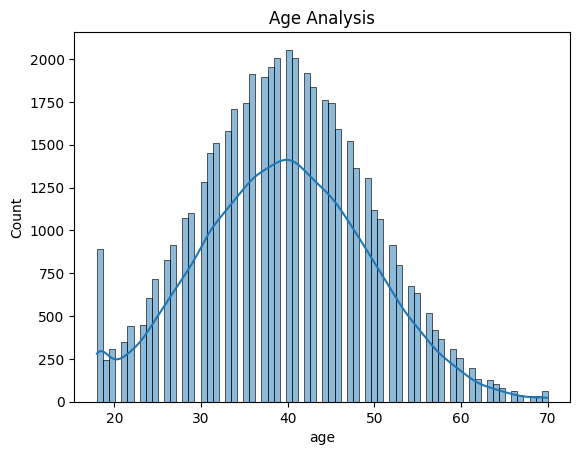

In [23]:
#Analyse the age column
sns.histplot(df['age'],kde=True)
plt.title('Age Analysis')
plt.show()

The `age` distribution ranges from `18 to 70` with most customers concentrated between `30 and 50` years. The distribution is approximately symmetric with no significant outliers. Therefore, no transformation was required for this feature.

# Income Column Analysis

In [24]:
df['income'].describe()

count      50000.00
mean     2640897.50
std      2629441.06
min            0.00
25%       803000.00
50%      1892000.00
75%      3332250.00
max     11999000.00
Name: income, dtype: float64

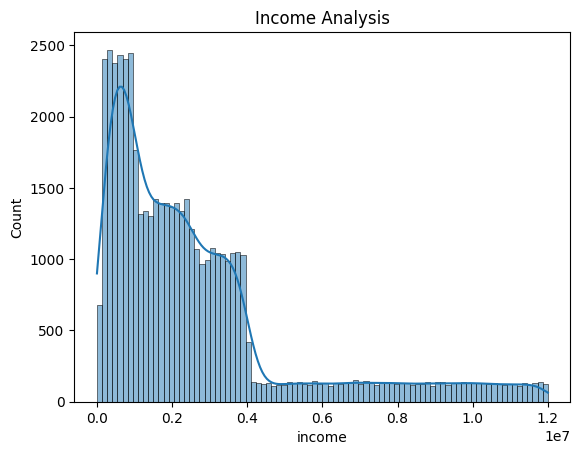

In [25]:
plt.title("Income Analysis")
sns.histplot(df['income'],kde=True)
plt.show()

In [26]:
#Handle Zero Income
df['income'] = df['income'].replace(0,np.nan)
df['income'] = df['income'].fillna(df['income'].median())

In [27]:
#Apply Log Transformation
df['income_log'] = np.log1p(df['income'])

<Axes: xlabel='income', ylabel='Count'>

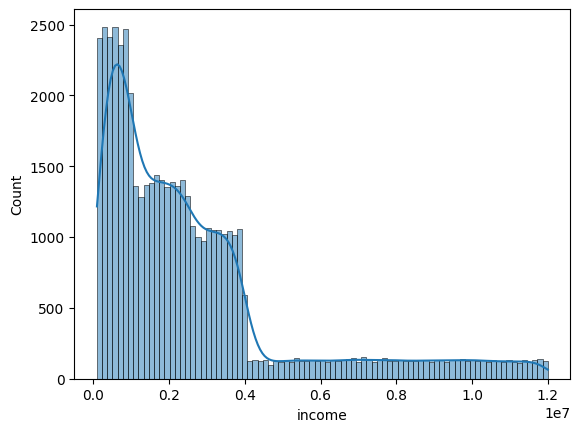

In [28]:
sns.histplot(df['income'],kde=True)

The `income` feature showed a right-skewed distribution with a smaller number of extremely high values. 
Additionally, a few records had zero income, which is not realistic for loan repayment. These values were replaced with median income.
A log transformation was applied to reduce skewness and imporve model performance.

# Gender Column Analysis

In [29]:
df['gender'].value_counts()

gender
M    29989
F    20011
Name: count, dtype: int64

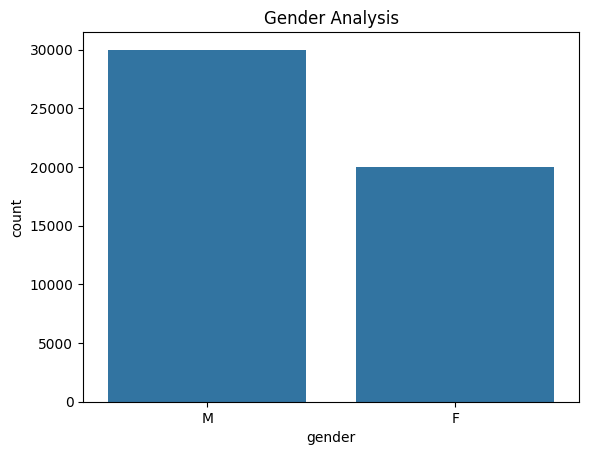

In [30]:
sns.countplot(x=df['gender'])
plt.title("Gender Analysis")
plt.show()

The `gender` feature consists of two categories, `male` and `female`, with a slight imbalance **60% Male, and 40% Female**.
No missing values were observed. The feature is suitable for one hot encoding without any additional preprocessing.

# Marital Status Column Analysis

In [31]:
df['marital_status'].value_counts()

marital_status
Married    27450
Single     22550
Name: count, dtype: int64

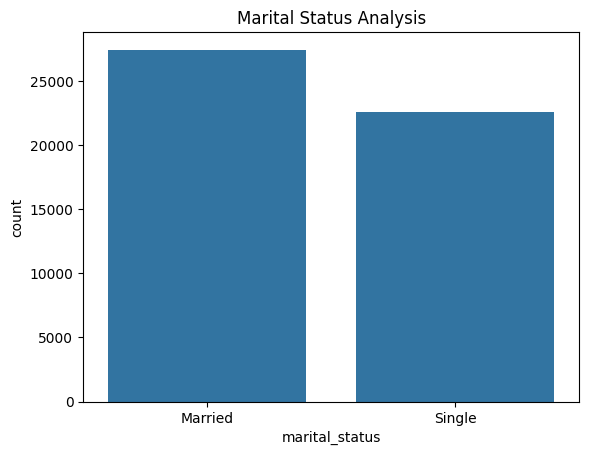

In [32]:
sns.countplot(x=df['marital_status'])
plt.title('Marital Status Analysis')
plt.show()

The `marital status` feature in is well balanced with approximately **55% married and 45% single** individuals. No missing or incosistent values were observed. The feature is retained and will be encoded using one hot encoding. 

# Employment Status Column Analysis

In [33]:
df['employment_status'].value_counts()

employment_status
Self-Employed    32183
Salaried         17817
Name: count, dtype: int64

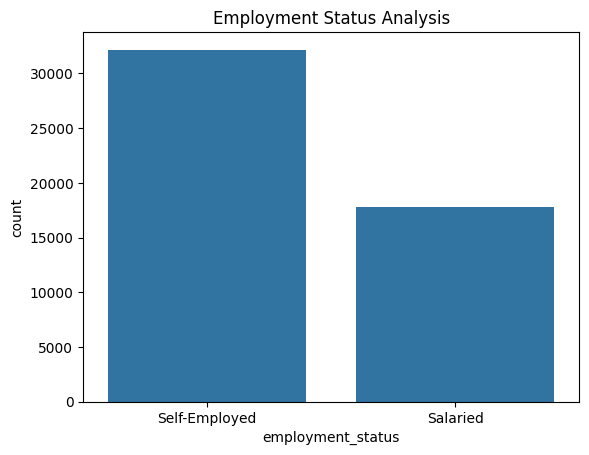

In [34]:
sns.countplot(x=df['employment_status'])
plt.title('Employment Status Analysis')
plt.show()

The `employment status` feature consists of **two categories: salaried and self-employed**. The data shows a higher proportion of self-employed individuals (~64%). This feature is important as `employment stability` is directly related to `credit risk`. It will be retained and encoded using one hot encoding.

# Number of Dependants Column Analysis

In [35]:
df['number_of_dependants'].describe()

count   50000.00
mean        1.94
std         1.54
min         0.00
25%         0.00
50%         2.00
75%         3.00
max         5.00
Name: number_of_dependants, dtype: float64

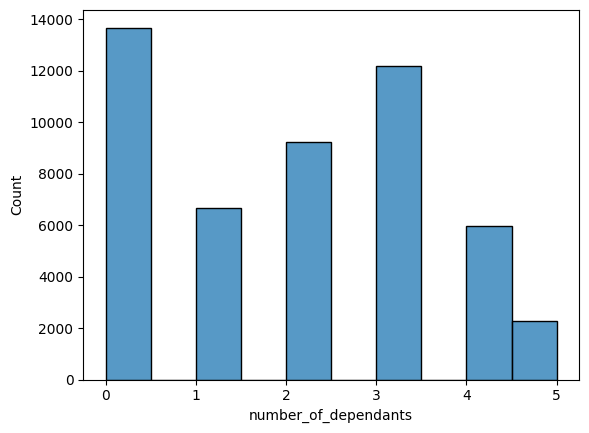

In [36]:
sns.histplot(df['number_of_dependants'],bins=10,kde=False)
plt.show()

The `number of dependants` ranges from **0 to 5**, with most customers having between **0 and 3** dependants. The feature reflects financial responsibility and may influence repayment capacity. No missing values or anamolies observed, so this feature is as-is.

# Residence Type Column Analysis

In [37]:
df['residence_type'].value_counts()

residence_type
Owned       28238
Mortgage    11819
Rented       9881
Name: count, dtype: int64

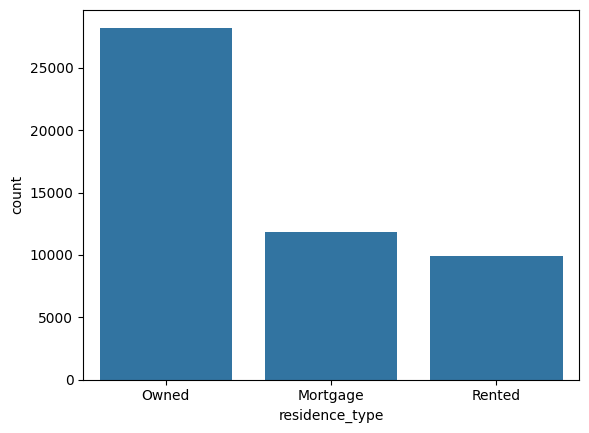

In [38]:
sns.countplot(x=df['residence_type'])
plt.show()

The `residence_type` feature includes **three categories: owned, mortgage, and rented.** A majority of customers own their residence (~56%) followed by mortgage (~24%) and rented (~20%). This feature is an important indicator of financial stability and is retained for modelling.

# Years At Current Address Column Analysis

In [39]:
df['years_at_current_address'].describe()

count   50000.00
mean       16.02
std         8.93
min         1.00
25%         8.00
50%        16.00
75%        24.00
max        31.00
Name: years_at_current_address, dtype: float64

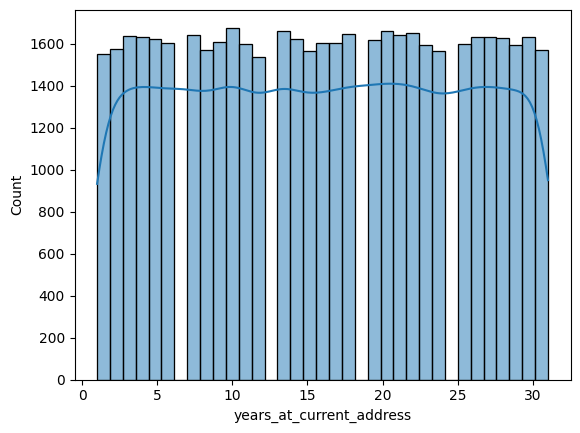

In [40]:
sns.histplot(df['years_at_current_address'],kde=True)
plt.show()

The `years_at_current_address` feature ranges from **1 to 31 years**, with mean of approximately **16** years.
The distribution is **fairly symmetric** with no extreme values. This feature is an important indicator of customer stability and is retained without transformation.

# City and State Column Analysis

In [41]:
df['city'].nunique()

10

In [42]:
df['state'].nunique()

9

The `city` and `state` features have low cardinality. (10 and 9 unique values respectively) making them suitable for one-hot encoding.
These features are important as geographic location can influence credit risk due to varying economic conditions.

# Loan Purpose Column Analysis

In [43]:
df['loan_purpose'].value_counts()

loan_purpose
Personal     17457
Home         15028
Auto          9936
Education     7557
Personaal       22
Name: count, dtype: int64

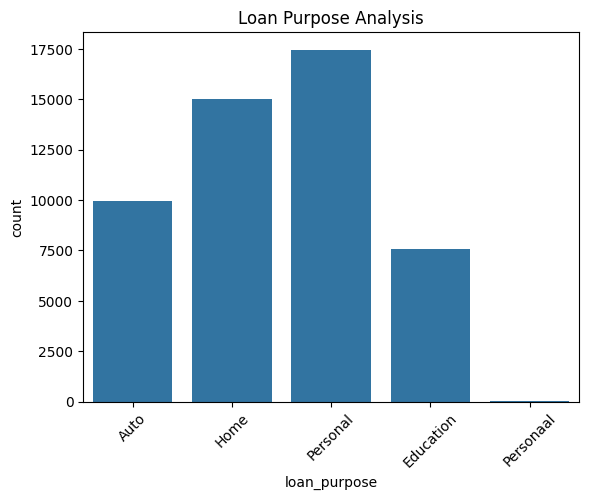

In [44]:
sns.countplot(x=df['loan_purpose'])
plt.xticks(rotation=45)
plt.title('Loan Purpose Analysis')
plt.show()

In [45]:
df['loan_purpose'] = df['loan_purpose'].replace('Personaal','Personal')

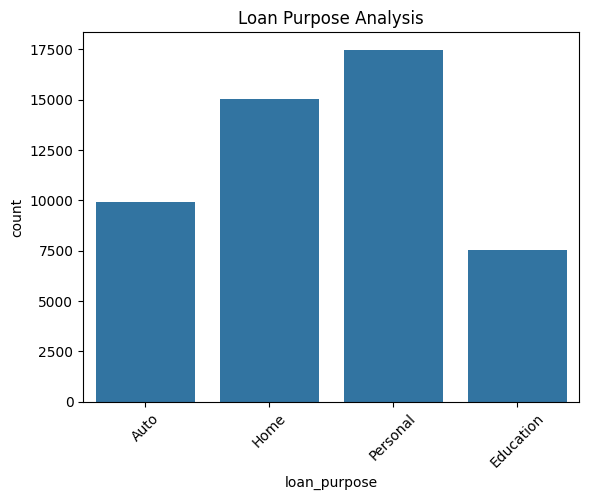

In [46]:
sns.countplot(x=df['loan_purpose'])
plt.xticks(rotation=45)
plt.title('Loan Purpose Analysis')
plt.show()

The `loan_purpose` feature contained a minor inconsistency due to typo (`Personaal`) , which was corrected to `Personal`. The feature includes categories such as **Personal, Education, Home, Auto** each representing different risk levels. This feature is retained for modelling.

# Loan Type Column Analysis

In [47]:
df['loan_type'].value_counts()

loan_type
Secured      32521
Unsecured    17479
Name: count, dtype: int64

sns.countplot(x=df['loan_type'])
plt.title('Loan Type Analysis')
plt.xticks(rotation=45)
plt.show()

The `loan_type` feature consists of **Secured** and **Unsecured** loans, with **Secured** loans forming the majority (~65%). Since **Unsecured** loans carry **higher** risk due to lack of collateral, this feature is expected to be a strong predictor of default. It is retained and will be encoded using one hot encoding. 

# Loan Amount Column Analysis 

In [48]:
df['loan_amount'].describe()

count      50000.00
mean     3999678.80
std      5376552.03
min            0.00
25%       967000.00
50%      2240000.00
75%      4611000.00
max     47819000.00
Name: loan_amount, dtype: float64

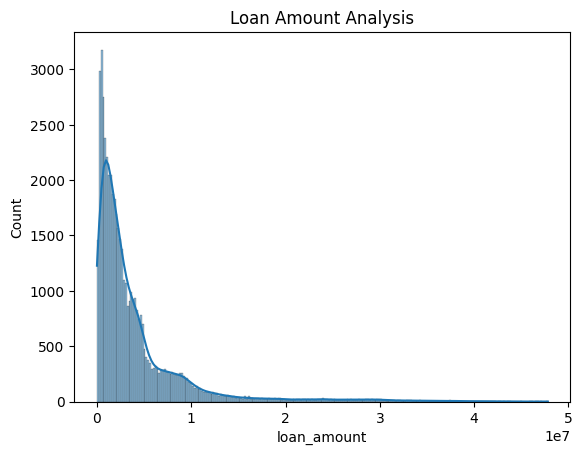

In [49]:
sns.histplot(df['loan_amount'],kde=True)
plt.title("Loan Amount Analysis")
plt.show()

# Interpretation of Loan Amount Analysis
## 1. Zero Loan Amount (Critical Issue)
`min=0` -> invalid
A loan of 0 does not make any sense\
Likely data error or placeholder

## 2. Highly Right-Skewed Distribution
**Mean > Median**
    -> Strong Positive Skew\
**Few very large loans dominate**
    -> Can distort model learning

## 3. Extreme Values 
**Max ~ 4.7 crore**
    -> Possibly Valid\
**Could act as outliers**\
May bias the model training

In [50]:
#Handle Zero Values
df['loan_amount'] = df['loan_amount'].replace(0,np.nan)
df['loan_amount'] = df['loan_amount'].fillna(df['loan_amount'].median())

In [51]:
df['loan_amount_log'] =  np.log1p(df['loan_amount'])

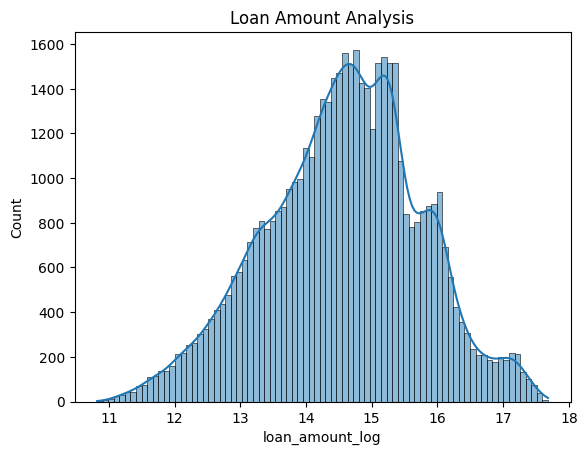

In [52]:
sns.histplot(df['loan_amount_log'],kde=True)
plt.title("Loan Amount Analysis")
plt.show()

The `loan_amount` feature showed a highly right-skewed distribution with a few extremely large values. 
Some records contained zero loan amounts, which are not realistic and were replaced by median. 
A log transformation was applied to reduce skewness and improve model stability

# Sanction Amount Column Analysis

In [53]:
df['sanction_amount'].describe()

count      50000.00
mean     4704827.52
std      6267276.39
min            0.00
25%      1147000.00
50%      2656000.00
75%      5172250.00
max     52175000.00
Name: sanction_amount, dtype: float64

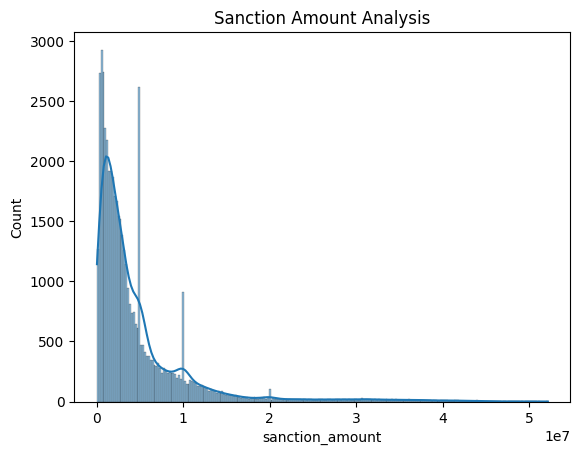

In [54]:
sns.histplot(x=df['sanction_amount'],kde=True)
plt.title("Sanction Amount Analysis")
plt.show()

In [55]:
df[['loan_amount','sanction_amount']].corr()

,loan_amount,sanction_amount
loan_amount,1.00,0.99
sanction_amount,0.99,1.00


In [56]:
#Before dropping, clean the sanction_amount data
df['sanction_amount'] = df['sanction_amount'].replace(0,np.nan)
df['sanction_amount'] = df['sanction_amount'].fillna(df['sanction_amount'].median())

The `sanction_amount` feature is highly correlated with loan amount, as it represents the approved loan value while `loan_amount` reflects the actual amount dispersed. To avoid multicollinearity and redudancy, `sanction_amount` was dropped and `loan_amount` was retained for modelling.

In [57]:
df.drop(columns=['sanction_amount'],inplace=True)

In [58]:
df.head(3)

,cust_id,age,gender,marital_status,employment_status,income,number_of_dependants,residence_type,years_at_current_address,city,...,number_of_closed_accounts,total_loan_months,delinquent_months,total_dpd,enquiry_count,credit_utilization_ratio,loan_to_income,credit_utilization_per_income,income_log,loan_amount_log
0,C00001,44,M,Married,Self-Employed,2586000.00,3,Owned,27,Delhi,...,1,42,0,0,3,7,0.95,7.34,14.77,14.72
1,C00002,38,M,Married,Salaried,1206000.00,3,Owned,4,Chennai,...,1,96,12,60,5,4,3.22,1.24,14.00,15.17
2,C00003,46,F,Married,Self-Employed,2878000.00,3,Owned,24,Kolkata,...,1,82,24,147,6,58,0.75,76.92,14.87,14.59


In [59]:
df.columns

Index(['cust_id', 'age', 'gender', 'marital_status', 'employment_status',
       'income', 'number_of_dependants', 'residence_type',
       'years_at_current_address', 'city', 'state', 'zipcode', 'loan_id',
       'loan_purpose', 'loan_type', 'loan_amount', 'processing_fee', 'gst',
       'net_disbursement', 'loan_tenure_months', 'principal_outstanding',
       'bank_balance_at_application', 'disbursal_date', 'installment_start_dt',
       'default', 'number_of_open_accounts', 'number_of_closed_accounts',
       'total_loan_months', 'delinquent_months', 'total_dpd', 'enquiry_count',
       'credit_utilization_ratio', 'loan_to_income',
       'credit_utilization_per_income', 'income_log', 'loan_amount_log'],
      dtype='str')

# Batch Analysis Columns

In [60]:
cols = [
    'processing_fee', 'gst', 'net_disbursement',
    'loan_tenure_months', 'bank_balance_at_application'
]

df[cols].describe()

,processing_fee,gst,net_disbursement,loan_tenure_months,bank_balance_at_application
count,50000.00,50000.00,50000.00,50000.00,50000.00
mean,80494.71,719942.18,3199743.04,25.94,989126.38
std,117312.26,967779.37,4301241.63,12.43,1046071.89
min,0.00,0.00,0.00,6.00,0.00
25%,19340.00,174060.00,773600.00,16.00,287007.50
50%,44800.00,403200.00,1792000.00,24.00,668525.00
75%,92240.00,829980.00,3688800.00,35.00,1238667.00
max,5698029.90,8607420.00,38255200.00,59.00,7846643.00


In [61]:
df.drop(columns=['processing_fee','gst','net_disbursement'],inplace=True)

In [62]:
df.columns

Index(['cust_id', 'age', 'gender', 'marital_status', 'employment_status',
       'income', 'number_of_dependants', 'residence_type',
       'years_at_current_address', 'city', 'state', 'zipcode', 'loan_id',
       'loan_purpose', 'loan_type', 'loan_amount', 'loan_tenure_months',
       'principal_outstanding', 'bank_balance_at_application',
       'disbursal_date', 'installment_start_dt', 'default',
       'number_of_open_accounts', 'number_of_closed_accounts',
       'total_loan_months', 'delinquent_months', 'total_dpd', 'enquiry_count',
       'credit_utilization_ratio', 'loan_to_income',
       'credit_utilization_per_income', 'income_log', 'loan_amount_log'],
      dtype='str')

Features such as `processing_fee`,`gst`,`net_disbursement` were found to be derived from `loan_amount` and therefore redundant. These were dropped to avoid multicollinearity. Loan Tenure and Bank Balance at application were retained as they provide meaningful information about repayment capacity and financial capacity.

# Credit Behaviour Features Analysis

In [63]:
cols = [
    'number_of_open_accounts',
    'number_of_closed_accounts',
    'total_loan_months',
    'enquiry_count',
    'credit_utilization_ratio'
]

df[cols].describe()

,number_of_open_accounts,number_of_closed_accounts,total_loan_months,enquiry_count,credit_utilization_ratio
count,50000.00,50000.00,50000.00,50000.00,50000.00
mean,2.50,1.00,76.13,5.01,43.36
std,1.12,0.81,43.76,2.03,29.36
min,1.00,0.00,1.00,1.00,0.00
25%,1.00,0.00,42.00,4.00,18.00
50%,3.00,1.00,71.00,5.00,39.00
75%,4.00,2.00,107.00,6.00,67.00
max,4.00,2.00,223.00,9.00,99.00


Credit Behaviour Features such as `number_of_accounts`, `enquiry_count` and `credit_utilization_ratio` provide insights into a customer's borrowing behaviour and financial discipline. These features were retained as they are strong indicators of **credit risk.**

In [64]:
df.drop(columns=['delinquent_months','total_dpd','principal_outstanding'],inplace=True)

In [65]:
df.columns

Index(['cust_id', 'age', 'gender', 'marital_status', 'employment_status',
       'income', 'number_of_dependants', 'residence_type',
       'years_at_current_address', 'city', 'state', 'zipcode', 'loan_id',
       'loan_purpose', 'loan_type', 'loan_amount', 'loan_tenure_months',
       'bank_balance_at_application', 'disbursal_date', 'installment_start_dt',
       'default', 'number_of_open_accounts', 'number_of_closed_accounts',
       'total_loan_months', 'enquiry_count', 'credit_utilization_ratio',
       'loan_to_income', 'credit_utilization_per_income', 'income_log',
       'loan_amount_log'],
      dtype='str')

In [66]:
df[['disbursal_date', 'installment_start_dt']].head()

,disbursal_date,installment_start_dt
0,2019-07-24,2019-08-10
1,2019-07-24,2019-08-15
2,2019-07-24,2019-08-21
3,2019-07-24,2019-08-09
4,2019-07-24,2019-08-02


In [67]:
df['disbursal_date'] = pd.to_datetime(df['disbursal_date'])
df['installment_start_dt'] = pd.to_datetime(df['installment_start_dt'])

In [68]:
df[['disbursal_date', 'installment_start_dt']].head()

,disbursal_date,installment_start_dt
0,2019-07-24,2019-08-10
1,2019-07-24,2019-08-15
2,2019-07-24,2019-08-21
3,2019-07-24,2019-08-09
4,2019-07-24,2019-08-02


In [69]:
df['days_to_first_installment'] = (
    df['installment_start_dt'] - df['disbursal_date']
).dt.days

In [70]:
df['days_to_first_installment'].describe()

count   50000.00
mean       15.54
std         8.65
min         1.00
25%         8.00
50%        16.00
75%        23.00
max        30.00
Name: days_to_first_installment, dtype: float64

In [71]:
df['disbursal_month'] = df['disbursal_date'].dt.month
df['disbursal_year'] = df['disbursal_date'].dt.year

In [72]:
df = df.drop(columns=['disbursal_date', 'installment_start_dt'])

Date features were converted into datetime format and used to derive meaningful variables such as the number of days between disbursal and the first installment. This captures repayment initiation behavior. Original date columns were dropped after feature extraction.

In [73]:
df.columns

Index(['cust_id', 'age', 'gender', 'marital_status', 'employment_status',
       'income', 'number_of_dependants', 'residence_type',
       'years_at_current_address', 'city', 'state', 'zipcode', 'loan_id',
       'loan_purpose', 'loan_type', 'loan_amount', 'loan_tenure_months',
       'bank_balance_at_application', 'default', 'number_of_open_accounts',
       'number_of_closed_accounts', 'total_loan_months', 'enquiry_count',
       'credit_utilization_ratio', 'loan_to_income',
       'credit_utilization_per_income', 'income_log', 'loan_amount_log',
       'days_to_first_installment', 'disbursal_month', 'disbursal_year'],
      dtype='str')

In [74]:
df = df.drop(columns=[
    'cust_id',
    'loan_id',
    'zipcode'
])

# Summary of EDA done for Credit Risk
1. The csv datasets were combined and built and then analysed, column wise.
2. Cleaning of data was done where ever required
3. Filling of missing and null values was done
4. Categorical options were unified if any spelling mistakes.
5. For each feature, plot was constructed so that the analysis can be done.

In [75]:
y = df['default']
X = df.drop(columns=['default'])

In [76]:
y.head()

0    False
1    False
2    False
3    False
4    False
Name: default, dtype: bool

In [77]:
X.head()

,age,gender,marital_status,employment_status,income,number_of_dependants,residence_type,years_at_current_address,city,state,...,total_loan_months,enquiry_count,credit_utilization_ratio,loan_to_income,credit_utilization_per_income,income_log,loan_amount_log,days_to_first_installment,disbursal_month,disbursal_year
0,44,M,Married,Self-Employed,2586000.00,3,Owned,27,Delhi,Delhi,...,42,3,7,0.95,7.34,14.77,14.72,17,7,2019
1,38,M,Married,Salaried,1206000.00,3,Owned,4,Chennai,Tamil Nadu,...,96,5,4,3.22,1.24,14.00,15.17,22,7,2019
2,46,F,Married,Self-Employed,2878000.00,3,Owned,24,Kolkata,West Bengal,...,82,6,58,0.75,76.92,14.87,14.59,28,7,2019
3,55,F,Single,Self-Employed,3547000.00,1,Owned,15,Bangalore,Karnataka,...,115,5,26,0.49,52.79,15.08,14.37,16,7,2019
4,37,M,Married,Salaried,3432000.00,3,Owned,28,Pune,Maharashtra,...,120,5,10,1.32,7.59,15.05,15.32,9,7,2019


In [78]:
categorical_cols = X.select_dtypes(include=['object', 'string', 'category']).columns.tolist()
numeric_cols = X.select_dtypes(exclude=['object', 'string', 'category']).columns.tolist()

In [79]:
categorical_cols

['gender',
 'marital_status',
 'employment_status',
 'residence_type',
 'city',
 'state',
 'loan_purpose',
 'loan_type']

In [80]:
numeric_cols

['age',
 'income',
 'number_of_dependants',
 'years_at_current_address',
 'loan_amount',
 'loan_tenure_months',
 'bank_balance_at_application',
 'number_of_open_accounts',
 'number_of_closed_accounts',
 'total_loan_months',
 'enquiry_count',
 'credit_utilization_ratio',
 'loan_to_income',
 'credit_utilization_per_income',
 'income_log',
 'loan_amount_log',
 'days_to_first_installment',
 'disbursal_month',
 'disbursal_year']

In [81]:
X[numeric_cols] = X[numeric_cols].replace([np.inf, -np.inf], np.nan)
X[numeric_cols] = X[numeric_cols].fillna(X[numeric_cols].median())

X[categorical_cols] = X[categorical_cols].fillna(
    X[categorical_cols].mode().iloc[0]
)

In [82]:
X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

In [83]:
X_encoded.head(3)

,age,income,number_of_dependants,years_at_current_address,loan_amount,loan_tenure_months,bank_balance_at_application,number_of_open_accounts,number_of_closed_accounts,total_loan_months,...,state_Maharashtra,state_Rajasthan,state_Tamil Nadu,state_Telangana,state_Uttar Pradesh,state_West Bengal,loan_purpose_Education,loan_purpose_Home,loan_purpose_Personal,loan_type_Unsecured
0,44,2586000.00,3,27,2467000.00,33,873386,1,1,42,...,False,False,False,False,False,False,False,False,False,False
1,38,1206000.00,3,4,3883000.00,30,464100,3,1,96,...,False,False,True,False,False,False,False,True,False,False
2,46,2878000.00,3,24,2170000.00,21,1476042,2,1,82,...,False,False,False,False,False,True,False,False,True,True


In [84]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [86]:
#Scaling only for Logistic Regression
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test_scaled[numeric_cols] = scaler.transform(X_test[numeric_cols])

In [87]:
from bayes_opt import BayesianOptimization
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

def lr_eval(C, max_iter):
    model = LogisticRegression(
        C=C,
        max_iter=int(max_iter),
        solver='liblinear'
    )
    return cross_val_score(
        model, X_train_scaled, y_train, cv=3, scoring='roc_auc'
    ).mean()

optimizer = BayesianOptimization(
    f=lr_eval,
    pbounds={'C': (0.01, 10), 'max_iter': (100, 500)},
    random_state=42
)

optimizer.maximize(init_points=5, n_iter=10)

best_params = optimizer.max['params']

lr_model = LogisticRegression(
    C=best_params['C'],
    max_iter=int(best_params['max_iter']),
    solver='liblinear'
)
lr_model.fit(X_train_scaled, y_train)

|   iter    |  target   |     C     | max_iter  |
-------------------------------------------------
| 1         | 0.9402039 | 3.7516557 | 480.28572 |
| 2         | 0.9402206 | 7.3226194 | 339.46339 |
| 3         | 0.9401535 | 1.5686262 | 162.39780 |
| 4         | 0.9400733 | 0.5902552 | 446.47045 |
| 5         | 0.9402157 | 6.0151389 | 383.22903 |
| 6         | 0.9402214 | 7.7608920 | 338.12781 |
| 7         | 0.9399475 | 0.2019132 | 302.40985 |
| 8         | 0.9402224 | 8.1318524 | 499.88708 |
| 9         | 0.9402199 | 7.2243261 | 100.06850 |
| 10        | 0.9392741 | 0.0479201 | 124.35079 |
| 11        | 0.9398232 | 0.1170365 | 363.45384 |
| 12        | 0.9402270 | 9.9982459 | 399.75992 |
| 13        | 0.9358407 | 0.0105949 | 415.99439 |
| 14        | 0.9402269 | 9.9006456 | 462.96311 |
| 15        | 0.9402117 | 5.1171389 | 182.03680 |


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",np.float64(9.998245942834885)
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of

In [88]:
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5],
    'learning_rate': [0.01, 0.1]
}

xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss')

grid = GridSearchCV(
    xgb, param_grid, cv=3, scoring='roc_auc', n_jobs=-1
)

grid.fit(X_train, y_train)
best_model = grid.best_estimator_

C:\Users\manan\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\xgboost\training.py:200: UserWarning: [10:43:22] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [89]:
#Evaluation of the model
from sklearn.metrics import roc_auc_score

# Logistic
lr_auc = roc_auc_score(y_test, lr_model.predict_proba(X_test_scaled)[:,1])

# XGBoost
xgb_auc = roc_auc_score(y_test, best_model.predict_proba(X_test)[:,1])

print("LR ROC-AUC:", lr_auc)
print("XGB ROC-AUC:", xgb_auc)

LR ROC-AUC: 0.9447177252407919
XGB ROC-AUC: 0.965699322692384


In [90]:
corr = pd.concat([X_encoded, y], axis=1).corr()['default'].sort_values(ascending=False)
print(corr.head(10))

default                         1.00
credit_utilization_ratio        0.40
loan_to_income                  0.20
loan_purpose_Home               0.16
residence_type_Rented           0.14
loan_tenure_months              0.12
credit_utilization_per_income   0.11
loan_amount                     0.08
loan_amount_log                 0.07
loan_purpose_Education          0.02
Name: default, dtype: float64


In [91]:
#Model Training Complete
import joblib

joblib.dump(best_model, '../models/model.pkl')
joblib.dump(scaler, '../models/scaler.pkl')
joblib.dump(X_train.columns, '../models/columns.pkl')

['../models/columns.pkl']

In [93]:
joblib.dump(numeric_cols, '../models/numeric_cols.pkl')

['../models/numeric_cols.pkl']

In [94]:
X_train.mean().to_csv('../models/means.csv')

In [95]:
joblib.dump(categorical_cols, '../models/categorical_cols.pkl')

['../models/categorical_cols.pkl']

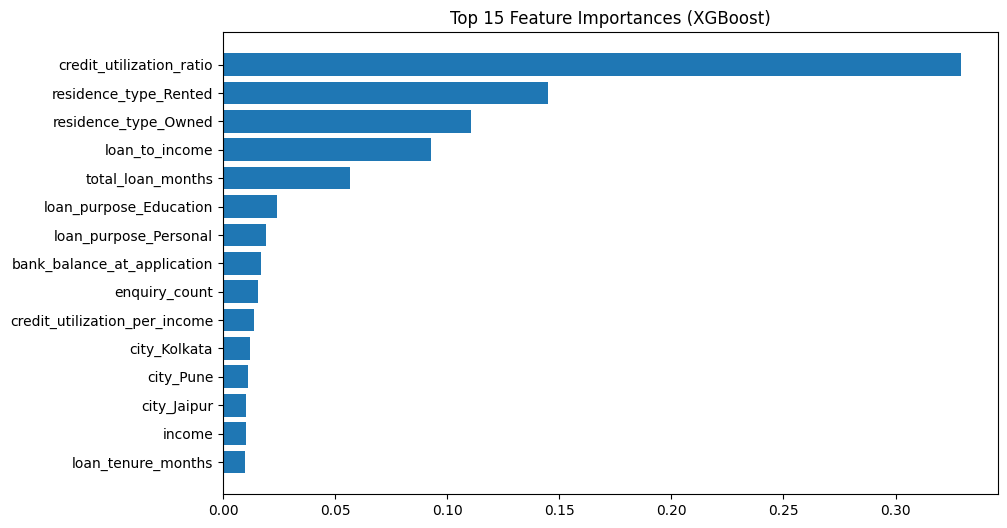

In [96]:
importance = best_model.feature_importances_

# Create dataframe
feat_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': importance
}).sort_values(by='importance', ascending=False)

# Top 15
top_features = feat_importance.head(15)

# Plot
plt.figure(figsize=(10,6))
plt.barh(top_features['feature'], top_features['importance'])
plt.gca().invert_yaxis()
plt.title("Top 15 Feature Importances (XGBoost)")
plt.show()